# Visualizations NBA
### Nesta etapa do projeto, transformaremos os dados processados em insights visuais para entender o desempenho de jogadores e equipes.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

try:
    df = pd.read_csv('../data/processed/clean_games.csv')
    print(f"Dataset carregado com sucesso! Linhas: {df.shape[0]}, Colunas: {df.shape[1]}")
except FileNotFoundError:
    print("Erro: Arquivo não encontrado. Verifique se o nome em 'data/processed' está correto.")

Dataset carregado com sucesso! Linhas: 26523, Colunas: 7


# Líderes de Pontuação:
### Comparativo direto das médias de pontos marcados em casa e fora de casa pelos líderes da liga


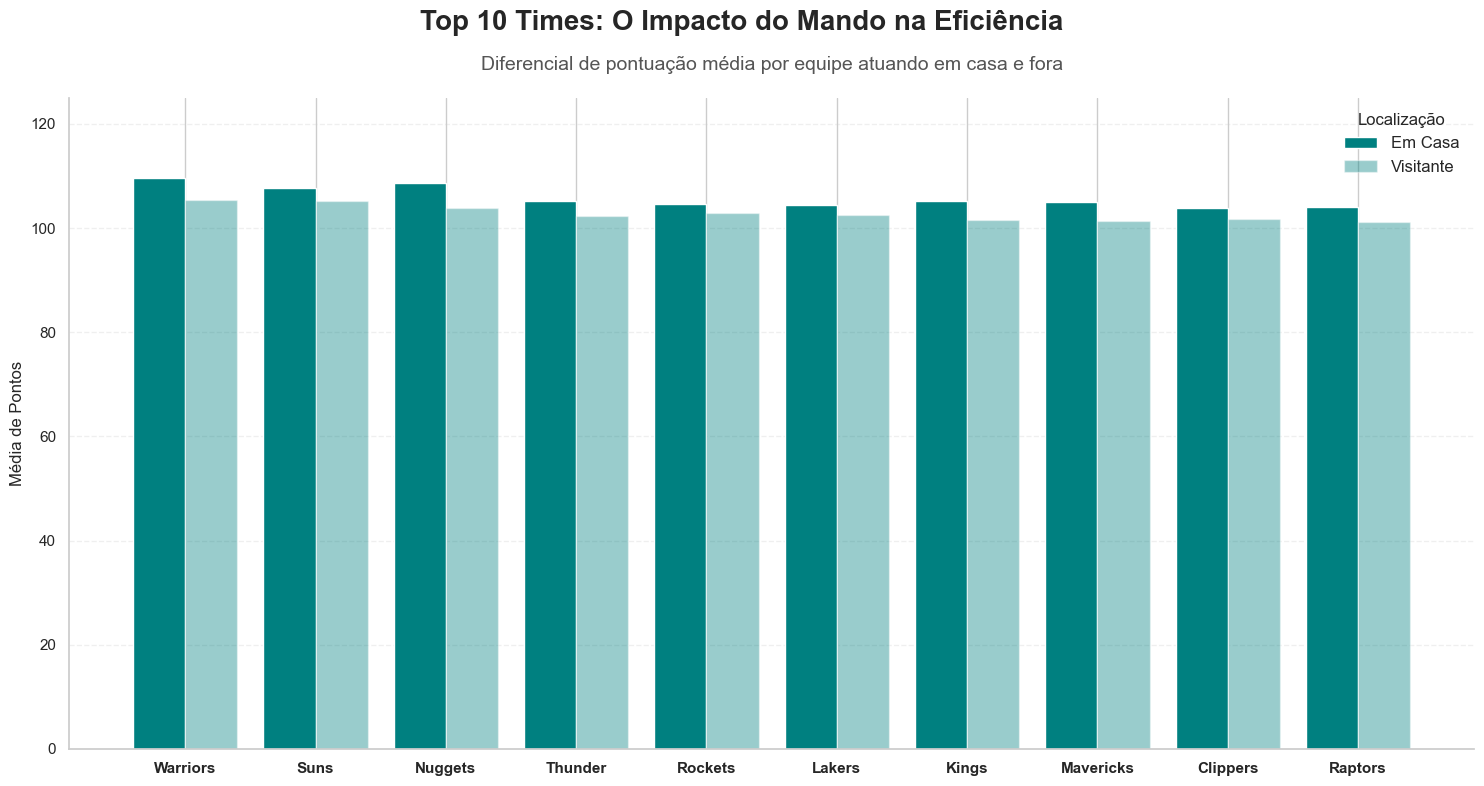

In [ ]:
import numpy as np
import matplotlib.patches as mpatches
import os

# 1. Definição da cor atrativa (Teal / Azul-Petróleo)
cor_principal = '#008080' 

# 2. Carregar nomes e calcular médias
try:
    df_teams = pd.read_csv('../data/processed/clean_teams.csv')
    team_map = df_teams.set_index('TEAM_ID')['NICKNAME'].to_dict()
except:
    team_map = {}

avg_home = df.groupby('HOME_TEAM_ID')['PTS_home'].mean()
avg_away = df.groupby('VISITOR_TEAM_ID')['PTS_away'].mean()

df_compare = pd.DataFrame({'Casa': avg_home, 'Visitante': avg_away})
df_compare.index = [team_map.get(i, i) for i in df_compare.index]
df_compare['Geral'] = (df_compare['Casa'] + df_compare['Visitante']) / 2
df_top10 = df_compare.sort_values('Geral', ascending=False).head(10).drop(columns='Geral')

# 3. Configuração do gráfico
fig, ax = plt.subplots(figsize=(15, 8))
width = 0.4  # Barras bem largas
x = np.arange(len(df_top10))

# 4. Plotagem das barras
# Barra da Casa (Cor Sólida)
rects1 = ax.bar(x - width/2, df_top10['Casa'], width, 
                color=cor_principal, label='Em Casa', edgecolor=None)

# Barra do Visitante (Mesma cor, mas com transparência para suavizar)
rects2 = ax.bar(x + width/2, df_top10['Visitante'], width, 
                color=cor_principal, alpha=0.4, label='Visitante', edgecolor=None)

# 5. Ajustes de Estilo e Títulos (Atualizados conforme nossa conversa)
plt.suptitle('Top 10 Times: O Impacto do Mando na Eficiência', fontsize=20, fontweight='bold', y=0.98)
ax.set_title('Diferencial de pontuação média por equipe atuando em casa e fora', fontsize=14, color='#555555', pad=20)

ax.set_ylabel('Média de Pontos', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(df_top10.index, fontsize=11, fontweight='bold')

# Escala e Grade
ax.set_yticks(np.arange(0, 121, 20)) # Ajustado para 20 em 20 para ficar mais limpo
ax.set_ylim(0, 125)
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.legend(title='Localização', frameon=False, fontsize=12)

# Remover as linhas das bordas
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

# --- CAMINHO DE SALVAMENTO ---
# Define o nome do arquivo conforme sua estrutura de pastas
nome_arquivo = "comparacao_media.png"
plt.savefig(f"../visualizations/{nome_arquivo}", dpi=300, bbox_inches='tight')
plt.show()

## Conclusão:
>Neste gráfico, fica nítido que o "fator casa" é uma realidade absoluta para a elite da NBA: todas as dez equipes analisadas pontuam mais em seus domínios do que como visitantes. Isso mostra que o mando de campo funciona como um multiplicador de eficiência, elevando o teto ofensivo dos times. Outro ponto importante é a consistência dessa elite, que consegue manter médias acima de 100 pontos mesmo sob a pressão de jogar fora de casa. Enquanto o Golden State Warriors aparece com o maior pico de pontuação em casa, equipes como o Clippers mostram maior equilíbrio, indicando que sua estratégia ofensiva sofre menos impacto independentemente do ginásio. Em resumo, o conforto do ginásio e o apoio da torcida não são apenas psicológicos, mas dados mensuráveis que definem o placar final.

# Casa vs Visitante: Quem Vence Mais?
### Comparativo percentual de resultados na liga.

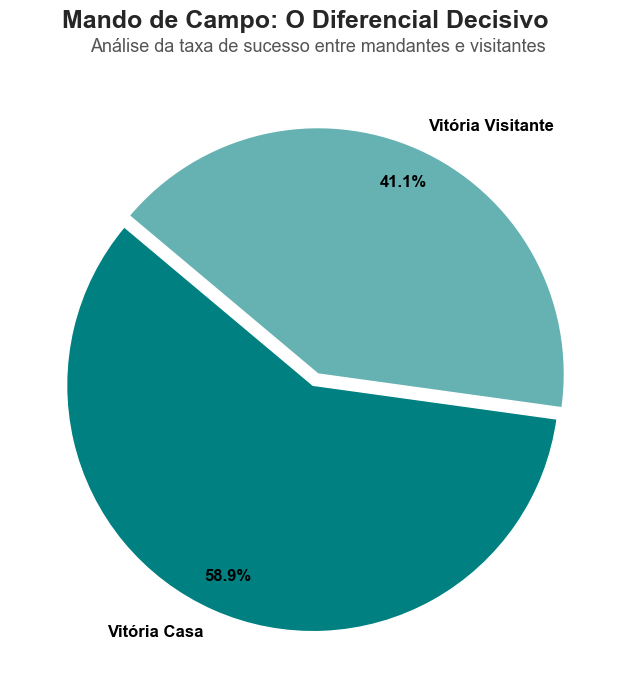

In [ ]:
# 1. Definindo as cores baseadas no padrão anterior
cor_casa = '#008080'      # Teal Sólido
cor_visitante = '#66B2B2' # Teal Claro

# 2. Criando a lógica de vitória
# Se o time da casa fez mais pontos, vitória da casa (True), caso contrário (False)
df['home_win'] = df['PTS_home'] > df['PTS_away']

# 3. Contabilizando os resultados
win_counts = df['home_win'].value_counts()

# 4. Criando o gráfico de pizza
plt.figure(figsize=(10, 8)) # Aumentado levemente para acomodar os títulos
plt.pie(win_counts, 
        labels=['Vitória Casa', 'Vitória Visitante'], 
        autopct='%1.1f%%', 
        colors=[cor_casa, cor_visitante], 
        startangle=140,
        pctdistance=0.85, # Afasta a porcentagem do centro para melhor leitura
        explode=(0.05, 0), # Dá um leve destaque na fatia de vitórias em casa
        textprops={'fontsize': 12, 'fontweight': 'bold', 'color': 'black'})

# Adicionando um círculo no meio para transformar em "Donut" (opcional, mas fica mais moderno)
# centre_circle = plt.Circle((0,0),0.70,fc='white')
# fig = plt.gcf()
# fig.gca().add_artist(centre_circle)

# 5. Títulos e Subtítulos ajustados
plt.suptitle('Mando de Campo: O Diferencial Decisivo', fontsize=18, fontweight='bold', y=0.95)
plt.title('Análise da taxa de sucesso entre mandantes e visitantes', fontsize=13, color='#555555', pad=10)

# --- CAMINHO DE SALVAMENTO ---
nome_arquivo = "taxa_de_sucesso.png"
plt.savefig(f"../visualizations/{nome_arquivo}", dpi=300, bbox_inches='tight')
plt.show()

# Conclusão
>Este gráfico confirma a existência de uma vantagem sólida e mensurável para os mandantes, com as vitórias em casa representando quase 59% do total de resultados. Esse percentual demonstra que o mando de campo é um fator determinante na liga, criando um desequilíbrio estatístico favorável a quem joga sob seus domínios. Embora as equipes visitantes consigam ser competitivas e garantir cerca de 41% das vitórias, a dominância dos times da casa sugere que variáveis como o apoio da torcida, a ausência de deslocamentos e a familiaridade com o ambiente exercem uma influência direta no aproveitamento final das partidas. Em suma, os dados ratificam que jogar em casa não é apenas uma conveniência, mas uma vantagem competitiva consolidada.

# Séries Temporais de Pontuação: Casa vs Visitante
### Análise da vantagem competitiva acumulada nas últimas décadas.

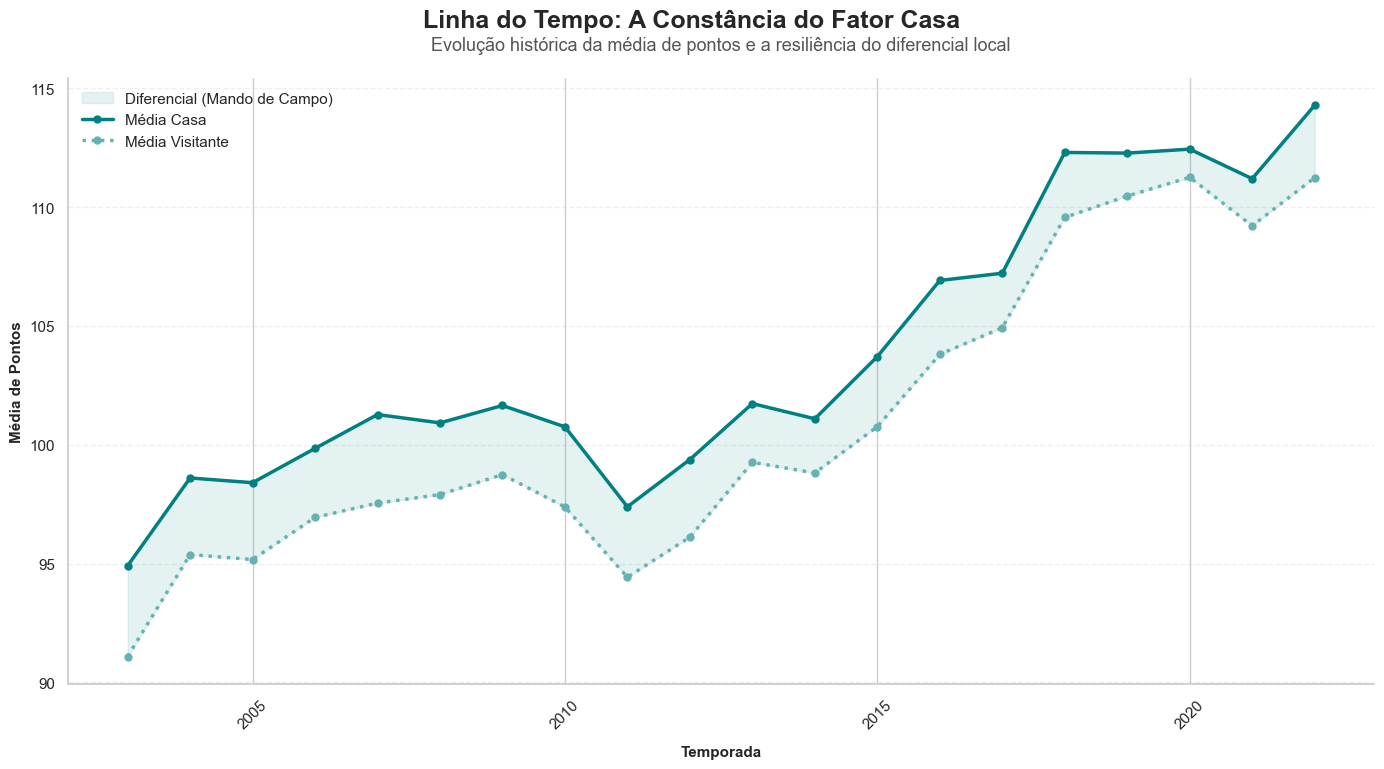

In [ ]:
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt

if 'SEASON' in df.columns:
    # 1. Preparação dos dados
    seasonal_avg = df.groupby('SEASON')[['PTS_home', 'PTS_away']].mean().sort_index()
    
    plt.figure(figsize=(14, 8)) # Aumentado para acomodar subtítulo

    cor_casa = '#008080'      
    cor_visitante = '#66B2B2' 

    # 2. Plotagem com preenchimento (Gera clareza visual no diferencial)
    plt.fill_between(seasonal_avg.index, seasonal_avg['PTS_home'], seasonal_avg['PTS_away'], 
                     color=cor_casa, alpha=0.1, label='Diferencial (Mando de Campo)')

    # Linha da Casa
    plt.plot(seasonal_avg.index, seasonal_avg['PTS_home'], 
             marker='o', markersize=5, linewidth=2.5, 
             label='Média Casa', color=cor_casa, antialiased=True)
    
    # Linha do Visitante (Pontilhada para contraste)
    plt.plot(seasonal_avg.index, seasonal_avg['PTS_away'], 
             marker='o', markersize=5, linewidth=2.5, linestyle=':',
             label='Média Visitante', color=cor_visitante, antialiased=True)
    
    # 3. Ajustes de Títulos e Subtítulos (Conforme definido)
    plt.suptitle('Linha do Tempo: A Constância do Fator Casa', fontsize=18, fontweight='bold', y=0.96)
    plt.title('Evolução histórica da média de pontos e a resiliência do diferencial local', 
              fontsize=13, color='#555555', pad=20)

    # 4. Melhoria nos Eixos
    ax = plt.gca()
    # Mostra um rótulo a cada 5 anos para evitar poluição visual
    ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
    
    plt.xlabel('Temporada', fontsize=11, fontweight='bold', labelpad=10)
    plt.ylabel('Média de Pontos', fontsize=11, fontweight='bold')
    
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.legend(frameon=False, loc='upper left', fontsize=11)
    plt.xticks(rotation=45)
    
    plt.tight_layout()

    # --- CAMINHO DE SALVAMENTO ---
    nome_arquivo = "evolucao_media_pontos.png"
    plt.savefig(f"../visualizations/{nome_arquivo}", dpi=300, bbox_inches='tight')

    plt.show()
else:
    print("Coluna 'SEASON' não encontrada.")

# Conclusão
>Este gráfico revela um crescimento constante no volume de pontuação da liga, mostrando que a vantagem do mandante é uma constante histórica resiliente. A área sombreada evidencia que, mesmo com as mudanças táticas ao longo das décadas, o time da casa sustenta um desempenho ofensivo superior de forma ininterrupta. Nota-se que, apesar da aceleração acentuada nos pontos a partir de 2015, o "gap" do mando de campo permaneceu estável. Em suma, os dados ratificam que a vantagem local é uma característica estrutural da liga, sobrevivendo à evolução da eficiência ofensiva.

# Distribuição de Frequência por Faixas de Pontuação
### Comparativo da frequência de pontuação entre casa e visitante.

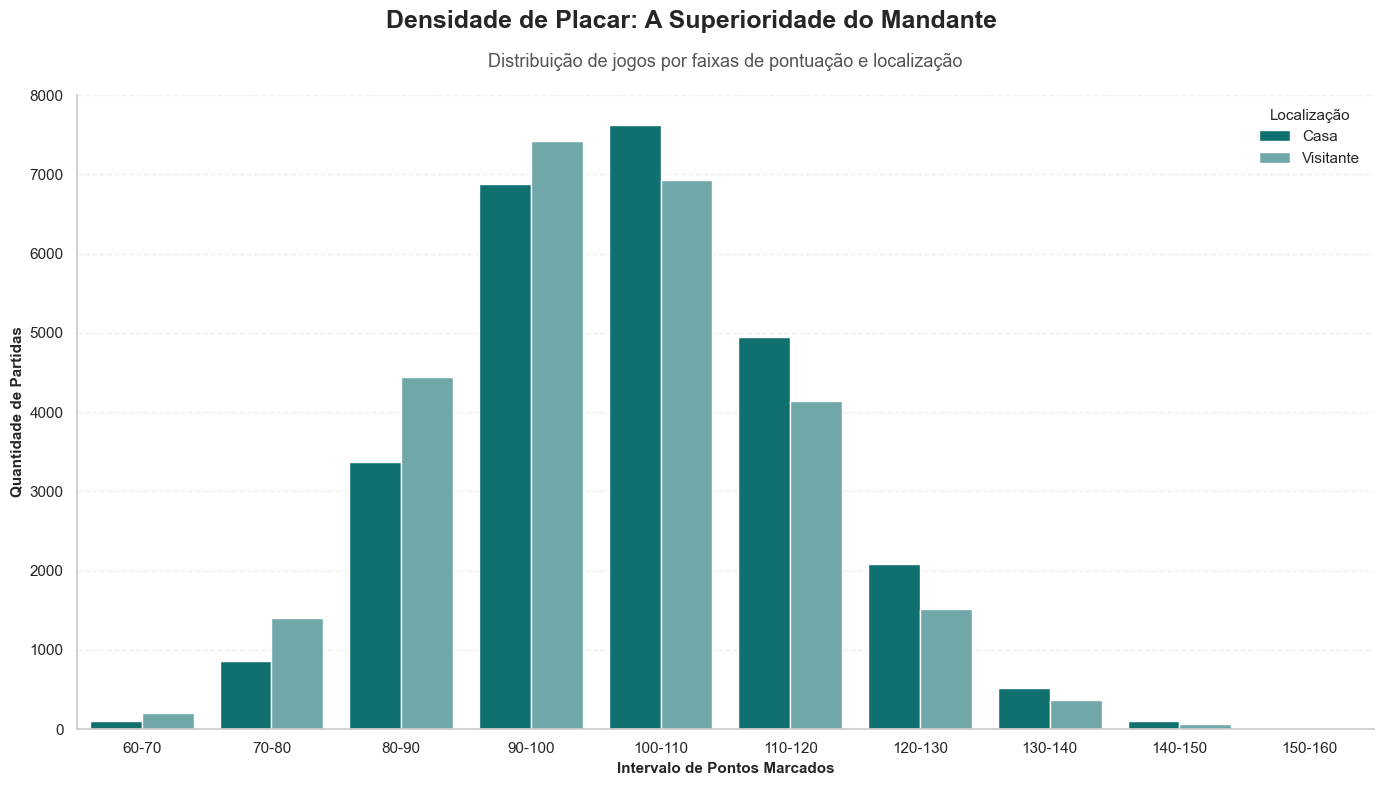

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Preparar os dados: Criar faixas (bins) de pontuação
bins = np.arange(60, 170, 10) 
labels = [f'{i}-{i+10}' for i in bins[:-1]]

# Criar DataFrame temporário para as faixas
df_bins = pd.DataFrame()
df_bins['faixa_home'] = pd.cut(df['PTS_home'], bins=bins, labels=labels)
df_bins['faixa_away'] = pd.cut(df['PTS_away'], bins=bins, labels=labels)

# Contar ocorrências em cada faixa
home_counts = df_bins['faixa_home'].value_counts().sort_index()
away_counts = df_bins['faixa_away'].value_counts().sort_index()

# Criar DataFrame para plotagem (Melting para Seaborn)
df_plot_bins = pd.DataFrame({
    'Faixa': labels,
    'Casa': [home_counts.get(l, 0) for l in labels],
    'Visitante': [away_counts.get(l, 0) for l in labels]
}).melt(id_vars='Faixa', var_name='Local', value_name='Total de Jogos')

# 2. Configuração do Gráfico
plt.figure(figsize=(14, 8))

sns.barplot(data=df_plot_bins, x='Faixa', y='Total de Jogos', hue='Local',
            palette=['#008080', '#66B2B2'], 
            edgecolor=None, width=0.8)

# 3. Títulos e Subtítulos (Atualizados)
plt.suptitle('Densidade de Placar: A Superioridade do Mandante', fontsize=18, fontweight='bold', y=0.98)
plt.title('Distribuição de jogos por faixas de pontuação e localização', fontsize=13, color='#555555', pad=20)

plt.xlabel('Intervalo de Pontos Marcados', fontsize=11, fontweight='bold')
plt.ylabel('Quantidade de Partidas', fontsize=11, fontweight='bold')

# 4. Ajustes de Estilo e Escala
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.legend(frameon=False, title='Localização', title_fontsize='11')

plt.tight_layout()

# --- CAMINHO DE SALVAMENTO ---
nome_arquivo = "faixa_de_pontuacao.png"
plt.savefig(f"../visualizations/{nome_arquivo}", dpi=300, bbox_inches='tight')

plt.show()

# Conclusão 
>A distribuição por faixas de pontuação revela que o time da casa domina as categorias de maior performance ofensiva. Enquanto os visitantes têm maior frequência em placares baixos (até 100 pontos), os mandantes assumem o protagonismo em todos os intervalos superiores. Esse comportamento demonstra que o mando de campo não apenas eleva a média, mas reduz drasticamente a probabilidade de produções ofensivas insuficientes. Em suma, os dados confirmam que jogar em casa desloca a concentração de jogos para patamares de pontuação mais elevados.